# Exploratory EDA

Early exploratory notebook for cross-category user overlap. This is not the final project pipeline.

In [ ]:
# Key questions to answer:
# 1. How many users appear in 2+ categories? (cross-category overlap)
# 2. What does the cold-start distribution look like in Beauty?
# 3. Do users who are active in Clothing/Sports have enough Beauty interactions to learn a transfer mapping?
# 4. What are the rating/activity distributions per category?
# 5. What do cross-category purchase sequences look like temporally?

In [1]:
# !pip install requests pandas matplotlib seaborn matplotlib-venn

import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

COLORS = {'Beauty': '#e91e8c', 'Clothing': '#3f51b5', 'Sports': '#4caf50'}
SEED = 42

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
# Load data

In [ ]:
CATEGORIES = {
    'Beauty':   'Beauty_and_Personal_Care',
    'Clothing': 'Clothing_Shoes_and_Jewelry',
    'Sports':   'Sports_and_Outdoors',
}

KEEP_COLS = ['user_id', 'parent_asin', 'rating', 'timestamp',
             'verified_purchase', 'helpful_vote']

N_SAMPLES = 500_000   # rows per category

HF_BASE = (
    'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023'
    '/resolve/main/raw/review_categories'
)


def stream_category(cat_filename, n=N_SAMPLES, cols=KEEP_COLS):
    """Stream n rows from a category JSONL on HuggingFace Hub."""
    url = f"{HF_BASE}/{cat_filename}.jsonl"
    rows = []
    with requests.get(url, stream=True, timeout=60) as resp:
        resp.raise_for_status()
        for i, raw_line in enumerate(resp.iter_lines(decode_unicode=True)):
            if i >= n:
                break
            if raw_line:
                obj = json.loads(raw_line)
                rows.append({k: obj.get(k) for k in cols})
    return rows


dfs = {}
for name, fname in CATEGORIES.items():
    print(f"Streaming {name} ({fname}.jsonl) ...")
    rows = stream_category(fname)
    df = pd.DataFrame(rows)
    df['category']  = name
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
    df['rating']    = pd.to_numeric(df['rating'], errors='coerce')
    dfs[name] = df
    print(f"  âœ“ {len(df):,} rows | {df['user_id'].nunique():,} users "
          f"| {df['parent_asin'].nunique():,} items")

print('\nDone.')

Streaming Beauty (Beauty_and_Personal_Care.jsonl) ...
  âœ“ 500,000 rows | 93,012 users | 165,408 items
Streaming Clothing (Clothing_Shoes_and_Jewelry.jsonl) ...
  âœ“ 500,000 rows | 53,176 users | 281,283 items
Streaming Sports (Sports_and_Outdoors.jsonl) ...
  âœ“ 500,000 rows | 140,186 users | 199,655 items

Done.


In [ ]:
dfs['Beauty'].head()

,user_id,parent_asin,rating,timestamp,verified_purchase,helpful_vote,category
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B00Z03RC80,1.0,2021-03-26 07:24:14.733,True,0,Beauty
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B085PRT2MP,1.0,2021-03-05 03:46:17.684,True,0,Beauty
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B08G81QQ9L,5.0,2021-01-31 00:21:33.701,True,0,Beauty
3,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07YYG76X1,1.0,2021-01-03 19:09:41.786,True,0,Beauty
4,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07X4FKLNK,3.0,2020-02-10 05:39:55.358,True,0,Beauty


## Per-Category Statistics

In [4]:
summary = []
for name, df in dfs.items():
    summary.append({
        'Category': name,
        'Reviews': len(df),
        'Unique Users': df['user_id'].nunique(),
        'Unique Items': df['parent_asin'].nunique(),
        'Sparsity (%)': round(
            100 * (1 - len(df) / (df['user_id'].nunique() * df['parent_asin'].nunique())), 4
        ),
        'Avg Rating': round(df['rating'].mean(), 3),
        'Median reviews/user': df.groupby('user_id').size().median(),
        'Verified purchase %': round(100 * df['verified_purchase'].mean(), 1),
    })

pd.DataFrame(summary).set_index('Category')

,Reviews,Unique Users,Unique Items,Sparsity (%),Avg Rating,Median reviews/user,Verified purchase %
Category,,,,,,,
Beauty,500000,93012,165408,99.9968,4.232,2.0,80.1
Clothing,500000,53176,281283,99.9967,4.295,4.0,79.4
Sports,500000,140186,199655,99.9982,4.345,2.0,89.8


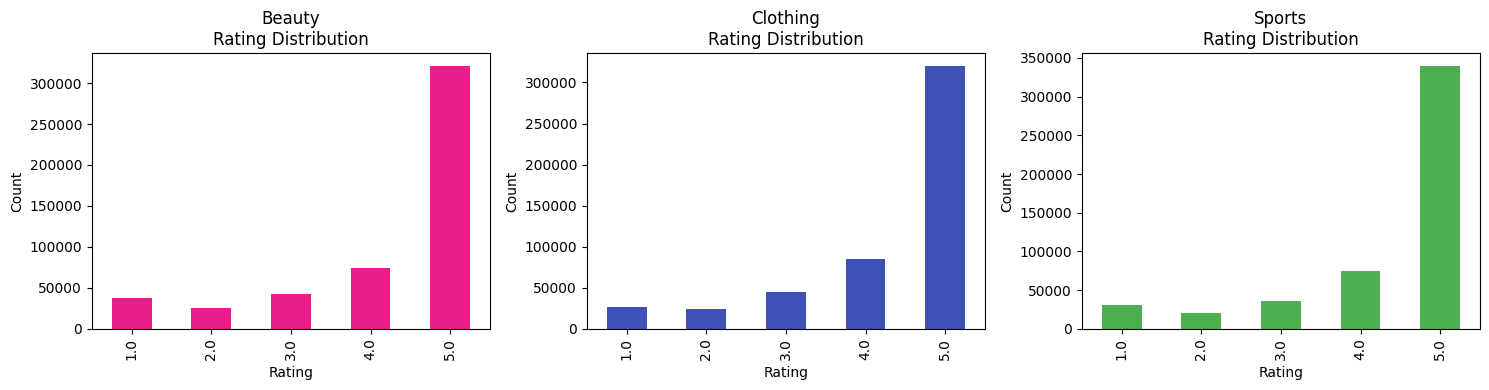

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, dfs.items()):
    df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color=COLORS[name])
    ax.set_title(f'{name}\nRating Distribution')
    ax.set_xlabel('Rating'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

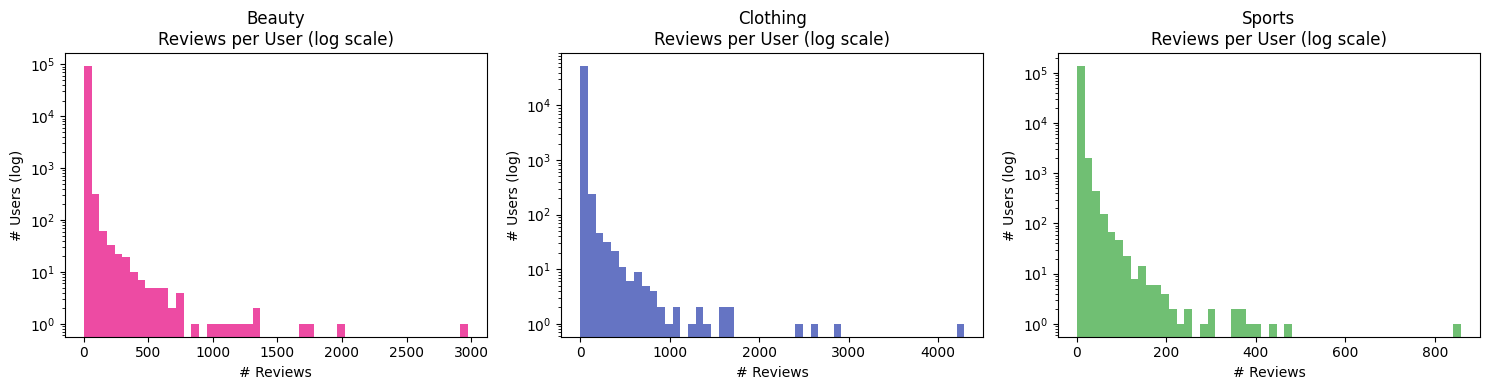

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, dfs.items()):
    user_counts = df.groupby('user_id').size()
    ax.hist(user_counts, bins=50, log=True, color=COLORS[name], alpha=0.8)
    ax.set_title(f'{name}\nReviews per User (log scale)')
    ax.set_xlabel('# Reviews'); ax.set_ylabel('# Users (log)')
plt.tight_layout(); plt.show()

## Cross-Category User Overlap

Key question: how many users appear in 2 or 3 categories?

In [7]:
user_sets = {name: set(df['user_id'].dropna()) for name, df in dfs.items()}

beauty_users   = user_sets['Beauty']
clothing_users = user_sets['Clothing']
sports_users   = user_sets['Sports']

overlap_bc  = beauty_users & clothing_users
overlap_bs  = beauty_users & sports_users
overlap_cs  = clothing_users & sports_users
overlap_all = beauty_users & clothing_users & sports_users

print('=== User Overlap ===')
print(f'Beauty only:          {len(beauty_users - clothing_users - sports_users):>10,}')
print(f'Clothing only:        {len(clothing_users - beauty_users - sports_users):>10,}')
print(f'Sports only:          {len(sports_users - beauty_users - clothing_users):>10,}')
print(f'Beauty âˆ© Clothing:    {len(overlap_bc):>10,}')
print(f'Beauty âˆ© Sports:      {len(overlap_bs):>10,}')
print(f'Clothing âˆ© Sports:    {len(overlap_cs):>10,}')
print(f'All three (Bâˆ©Câˆ©S):    {len(overlap_all):>10,}')
print(f'\nTotal unique users:   {len(beauty_users | clothing_users | sports_users):>10,}')

=== User Overlap ===
Beauty only:              25,581
Clothing only:            10,656
Sports only:              75,992
Beauty âˆ© Clothing:        33,909
Beauty âˆ© Sports:          55,583
Clothing âˆ© Sports:        30,672
All three (Bâˆ©Câˆ©S):        22,061

Total unique users:      188,271


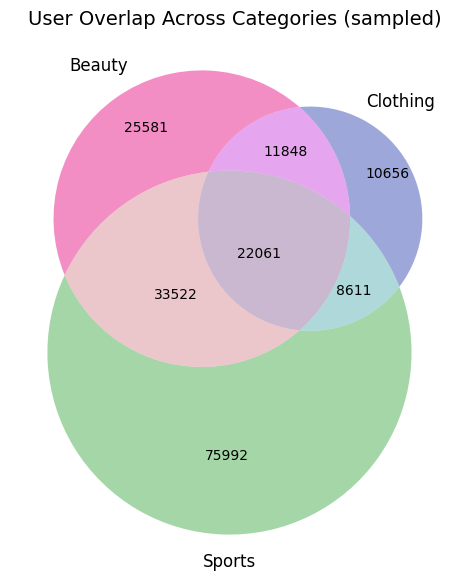

In [ ]:
from matplotlib_venn import venn3

plt.figure(figsize=(7, 7))
venn3(
    [beauty_users, clothing_users, sports_users],
    set_labels=('Beauty', 'Clothing', 'Sports'),
    set_colors=list(COLORS.values()),
    alpha=0.5
)
plt.title('User Overlap Across Categories (sampled)', fontsize=14)
plt.show()

In [35]:
print(f'\nAs % of Beauty users ({len(beauty_users):,}):')
print(f'  Beauty ∩ Clothing: {100*len(overlap_bc)/len(beauty_users):.1f}%')
print(f'  Beauty ∩ Sports:   {100*len(overlap_bs)/len(beauty_users):.1f}%')
print(f'  All three:         {100*len(overlap_all)/len(beauty_users):.1f}%')


As % of Beauty users (93,012):
  Beauty ∩ Clothing: 36.5%
  Beauty ∩ Sports:   59.8%
  All three:         23.7%


## Beauty Activity in Other Categories

In [9]:
COLD_THRESHOLD = 5

beauty_activity   = dfs['Beauty'].groupby('user_id').size().rename('beauty_count')
clothing_activity = dfs['Clothing'].groupby('user_id').size().rename('clothing_count')
sports_activity   = dfs['Sports'].groupby('user_id').size().rename('sports_count')

user_profile = (
    beauty_activity.to_frame()
    .join(clothing_activity, how='outer')
    .join(sports_activity,   how='outer')
    .fillna(0).astype(int)
)
user_profile['total_activity'] = user_profile.sum(axis=1)
user_profile['n_categories'] = (
    user_profile[['beauty_count', 'clothing_count', 'sports_count']] > 0
).sum(axis=1)

print(user_profile.describe().round(2))

       beauty_count  clothing_count  sports_count  total_activity  \
count     188271.00       188271.00     188271.00       188271.00   
mean           2.66            2.66          2.66            7.97   
std           16.95           22.33          6.60           38.34   
min            0.00            0.00          0.00            1.00   
25%            0.00            0.00          0.00            1.00   
50%            0.00            0.00          1.00            3.00   
75%            2.00            1.00          3.00            7.00   
max         2973.00         4294.00        858.00         6236.00   

       n_categories  
count     188271.00  
mean           1.52  
std            0.70  
min            1.00  
25%            1.00  
50%            1.00  
75%            2.00  
max            3.00  


In [34]:
in_beauty       = user_profile['beauty_count'] > 0
cold_in_beauty  = user_profile[in_beauty & (user_profile['beauty_count'] <  COLD_THRESHOLD)]
warm_in_beauty  = user_profile[in_beauty & (user_profile['beauty_count'] >= COLD_THRESHOLD)]

print(f'Users in Beauty dataset:      {in_beauty.sum():,}')
print(f'  Cold (<{COLD_THRESHOLD} reviews):        {len(cold_in_beauty):,} '
      f'({100*len(cold_in_beauty)/in_beauty.sum():.1f}%)')
print(f'  Warm ({COLD_THRESHOLD} reviews):        {len(warm_in_beauty):,}')

has_clothing = (cold_in_beauty['clothing_count'] >= COLD_THRESHOLD).sum()
has_sports   = (cold_in_beauty['sports_count']   >= COLD_THRESHOLD).sum()
has_either   = (
    (cold_in_beauty['clothing_count'] >= COLD_THRESHOLD) |
    (cold_in_beauty['sports_count']   >= COLD_THRESHOLD)
).sum()

print(f'\nOf cold Beauty users:')
print(f'  Warm in Clothing ({COLD_THRESHOLD}): {has_clothing:,}')
print(f'  Warm in Sports   ({COLD_THRESHOLD}): {has_sports:,}')
print(f'  Warm in EITHER:       {has_either:,} '
      f'({100*has_either/max(len(cold_in_beauty),1):.1f}% of cold users)')
# frac of cold users we can potentially help with cross cat trf ^

Users in Beauty dataset:      93,012
  Cold (<5 reviews):        66,964 (72.0%)
  Warm (5 reviews):        26,048

Of cold Beauty users:
  Warm in Clothing (5): 11,037
  Warm in Sports   (5): 6,208
  Warm in EITHER:       15,369 (23.0% of cold users)


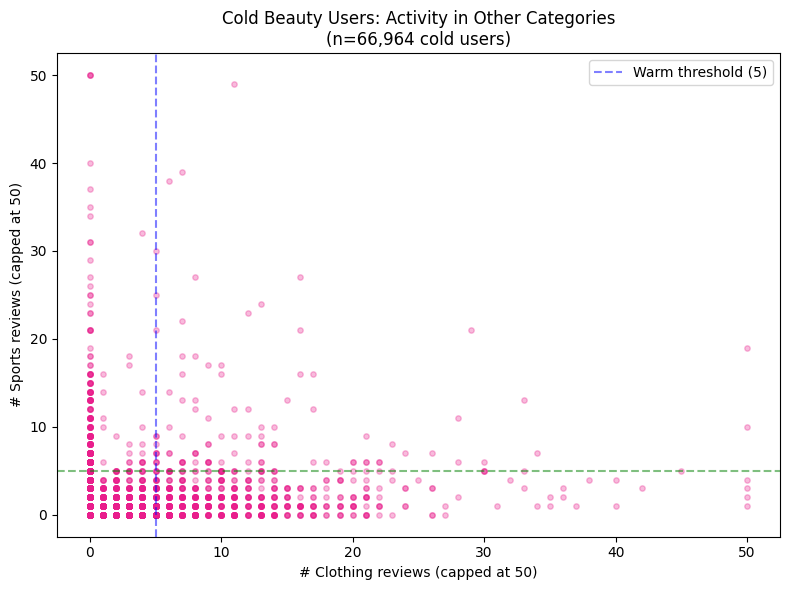

In [11]:
sample = cold_in_beauty.sample(min(5000, len(cold_in_beauty)), random_state=SEED)

plt.figure(figsize=(8, 6))
plt.scatter(
    sample['clothing_count'].clip(upper=50),
    sample['sports_count'].clip(upper=50),
    alpha=0.3, s=15, c='#e91e8c'
)
plt.xlabel('# Clothing reviews (capped at 50)')
plt.ylabel('# Sports reviews (capped at 50)')
plt.title(f'Cold Beauty Users: Activity in Other Categories\n'
          f'(n={len(cold_in_beauty):,} cold users)')
plt.axvline(x=COLD_THRESHOLD, color='blue', linestyle='--', alpha=0.5,
            label=f'Warm threshold ({COLD_THRESHOLD})')
plt.axhline(y=COLD_THRESHOLD, color='green', linestyle='--', alpha=0.5)
plt.legend(); plt.tight_layout(); plt.show()

## Temporal Patterns: Cross-Category Purchase Sequences

In [12]:
all_events = pd.concat([
    dfs[name][['user_id', 'parent_asin', 'timestamp', 'rating']].assign(category=name)
    for name in dfs
], ignore_index=True).sort_values('timestamp')

tri_users = list(overlap_all)
print(f'Users in all 3 categories: {len(tri_users):,}')

events_tri = all_events[all_events['user_id'].isin(tri_users)].copy()
print(f'Events for these users: {len(events_tri):,}')

Users in all 3 categories: 22,061
Events for these users: 675,440


First category entered (among users in all 3):
first_category
Clothing    10823
Beauty       5959
Sports       5279
Name: count, dtype: int64


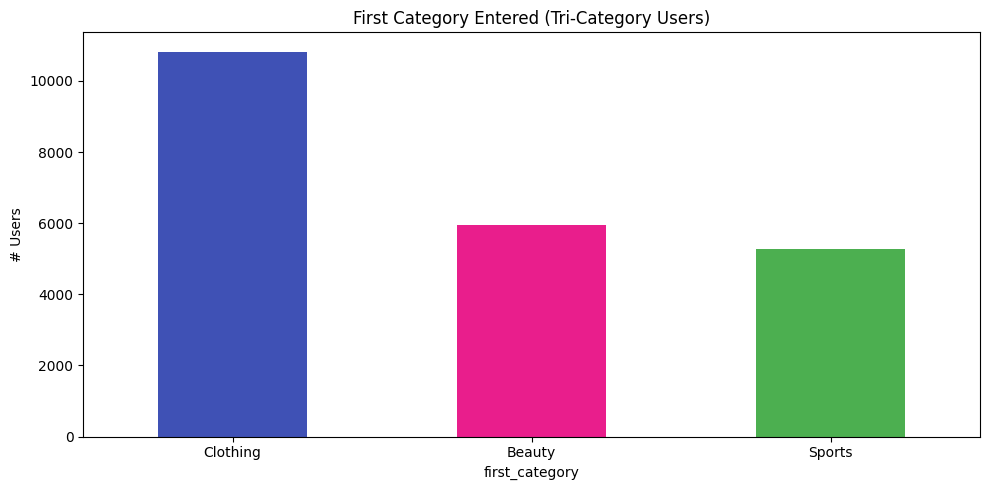

In [13]:
first_entry = (
    events_tri
    .sort_values('timestamp')
    .groupby(['user_id', 'category'])['timestamp']
    .min()
    .reset_index()
    .rename(columns={'timestamp': 'first_purchase'})
)

first_category = (
    first_entry
    .sort_values('first_purchase')
    .groupby('user_id')
    .first()
    .reset_index()
    .rename(columns={'category': 'first_category'})
)

print('First category entered (among users in all 3):')
print(first_category['first_category'].value_counts())

first_category['first_category'].value_counts().plot(
    kind='bar',
    color=[COLORS[c] for c in first_category['first_category'].value_counts().index],
    title='First Category Entered (Tri-Category Users)'
)
plt.ylabel('# Users')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

Users who entered Beauty AFTER another category: 22,061
count    22061.0
mean       611.8
std        823.4
min          0.0
25%          0.0
50%        246.0
75%        961.0
max       6031.0
Name: gap_days, dtype: float64


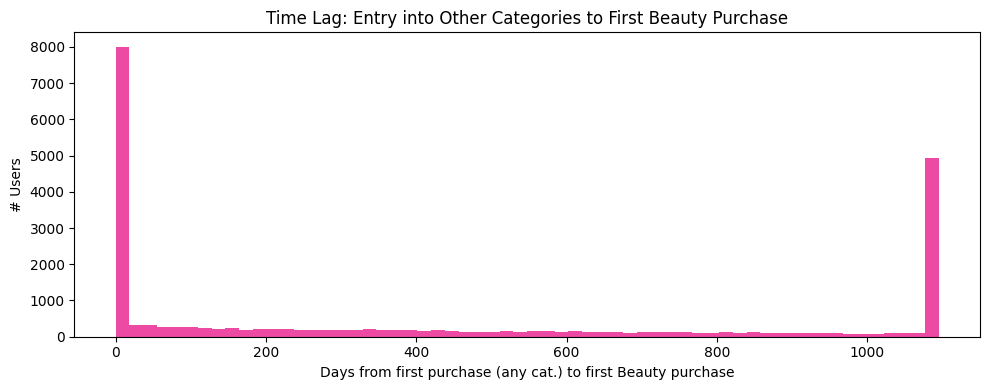

In [33]:
beauty_first = first_entry[first_entry['category'] == 'Beauty'].set_index('user_id')['first_purchase']
any_first    = first_entry.groupby('user_id')['first_purchase'].min()

gap_df = pd.DataFrame({'first_any': any_first, 'first_beauty': beauty_first}).dropna()
gap_df['gap_days'] = (gap_df['first_beauty'] - gap_df['first_any']).dt.days
gap_df = gap_df[gap_df['gap_days'] >= 0]

print(f'Users who entered Beauty AFTER another category: {len(gap_df):,}')
print(gap_df['gap_days'].describe().round(1))

plt.figure(figsize=(10, 4))
plt.hist(gap_df['gap_days'].clip(upper=365*3), bins=60,
         color=COLORS['Beauty'], alpha=0.8)
plt.xlabel('Days from first purchase (any cat.) to first Beauty purchase')
plt.ylabel('# Users')
plt.title('Time Lag: Entry into Other Categories to First Beauty Purchase')
plt.tight_layout(); plt.show()

## Cross-Category Rating Correlation

Users with avg ratings in all 3 categories: 22,061

Correlation matrix:
              avg_Beauty  avg_Clothing  avg_Sports
avg_Beauty         1.000         0.348       0.251
avg_Clothing       0.348         1.000       0.315
avg_Sports         0.251         0.315       1.000


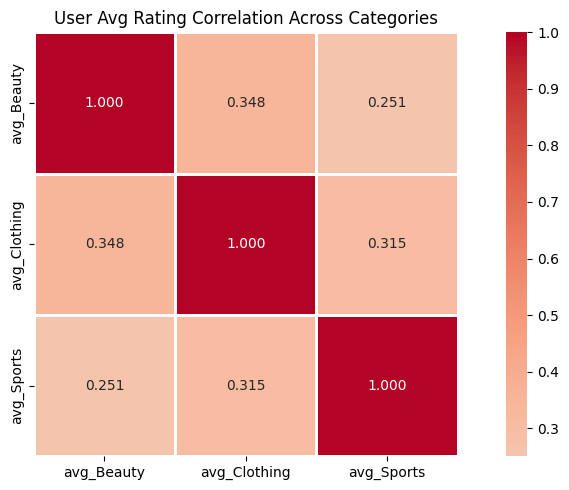

In [15]:
avg_ratings = {
    name: df.groupby('user_id')['rating'].mean().rename(f'avg_{name}')
    for name, df in dfs.items()
}

rating_profile = pd.concat(avg_ratings.values(), axis=1).dropna()
print(f'Users with avg ratings in all 3 categories: {len(rating_profile):,}')

corr = rating_profile.corr()
print('\nCorrelation matrix:')
print(corr.round(3))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1)
plt.title('User Avg Rating Correlation Across Categories')
plt.tight_layout(); plt.show()

## Item Metadata EDA

Item metadata (price, store, categories) for Beauty to understand available item features.

In [20]:
import requests, json

HF_META_BASE = (
    'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023'
    '/resolve/main/raw/meta_categories'
)

META_COLS = ['parent_asin', 'title', 'average_rating', 'rating_number',
             'price', 'main_category', 'store']

def stream_meta(cat_filename, n=100_000, cols=META_COLS):
    """Stream n rows of item metadata from HuggingFace Hub."""
    url = f"{HF_META_BASE}/{cat_filename}.jsonl"
    rows = []
    with requests.get(url, stream=True, timeout=60) as resp:
        resp.raise_for_status()
        for i, raw_line in enumerate(resp.iter_lines(decode_unicode=True)):
            if i >= n:
                break
            if raw_line:
                obj = json.loads(raw_line)
                rows.append({k: obj.get(k) for k in cols})
    return pd.DataFrame(rows)

In [23]:
HF_META_BASE = (
    'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023'
    '/resolve/main/raw/meta_categories'
)

META_COLS = ['parent_asin', 'title', 'average_rating', 'rating_number',
             'price', 'main_category', 'store']

def stream_meta(cat_filename, n=100_000, cols=META_COLS):
    """Stream n rows of item metadata from HuggingFace Hub.
    Note: metadata filenames have a 'meta_' prefix,
    e.g. meta_Beauty_and_Personal_Care.jsonl
    """
    url = f"{HF_META_BASE}/meta_{cat_filename}.jsonl"   # <-- meta_ prefix
    rows = []
    with requests.get(url, stream=True, timeout=60) as resp:
        resp.raise_for_status()
        for i, raw_line in enumerate(resp.iter_lines(decode_unicode=True)):
            if i >= n:
                break
            if raw_line:
                obj = json.loads(raw_line)
                rows.append({k: obj.get(k) for k in cols})
    return pd.DataFrame(rows)

meta_dfs = {}
for name, fname in CATEGORIES.items():
    print(f"Loading {name} metadata...")
    meta_dfs[name] = stream_meta(fname)
    print(f"  ✓ {len(meta_dfs[name]):,} items")

meta_dfs['Beauty'].head()

Loading Beauty metadata...
  ✓ 100,000 items
Loading Clothing metadata...
  ✓ 100,000 items
Loading Sports metadata...
  ✓ 100,000 items


,parent_asin,title,average_rating,rating_number,price,main_category,store
0,B08BLDKYHB,"Shiyeen 10 Colors Hair Chalk for Girls Gift, K...",3.9,57,None,All Beauty,shiyeen
1,B0BWJGQ32Y,"Ebbfurln Bob Wig Human Hair, 13x4 HD Lace Fron...",4.1,60,45.65,All Beauty,Ebbfurln
2,B07DC9S9PF,Makeup brush cleaner and dryer electronic spin...,4.4,7,None,All Beauty,J-ANKKA
3,B0BM8WLSXF,"3 Inch Clipper Guards, Hair Clipper Guide Comb...",4.0,68,24.99,All Beauty,CR8GR8
4,B00N4LMZZK,Cathy Doll L-Glutathione Magic Cream SPF 50 Wh...,4.0,65,14.99,All Beauty,Cathy Doll


In [28]:
beauty_meta = meta_dfs['Beauty']

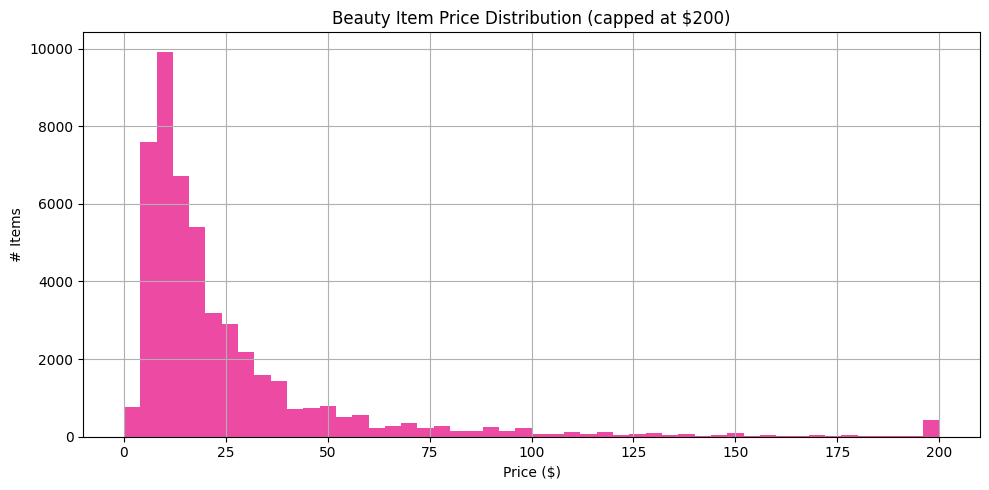

% items with price:   49.0%
% items with ratings: 100.0%

Top 15 stores:
store
Bath & Body Works          570
REVLON                     410
Maybelline New York        406
Generic                    346
Clinique                   328
L'Oreal Paris              299
Sally Hansen               286
COVERGIRL                  260
NYX PROFESSIONAL MAKEUP    232
Maitys                     211
KISS                       208
AVON                       207
Neutrogena                 201
L'Oréal Paris              200
Victoria's Secret          197
Name: count, dtype: int64


In [29]:
beauty_meta['price'] = pd.to_numeric(beauty_meta['price'], errors='coerce')
beauty_meta['price'].dropna().clip(upper=200).hist(
    bins=50, color=COLORS['Beauty'], alpha=0.8
)
plt.title('Beauty Item Price Distribution (capped at $200)')
plt.xlabel('Price ($)'); plt.ylabel('# Items')
plt.tight_layout(); plt.show()

print(f"% items with price:   {100*beauty_meta['price'].notna().mean():.1f}%")
print(f"% items with ratings: {100*beauty_meta['average_rating'].notna().mean():.1f}%")
print(f"\nTop 15 stores:")
print(beauty_meta['store'].value_counts().head(15))